# Reto 04 — Deep Q-Learning en LunarLander-v3

**Curso:** Aprendizaje por Refuerzo  
**Universidad:** Universidad EIA  
**Estudiante:** Camilo Zapata Cárdenas  
**Correo institucional:** camilo.zapata97@eia.edu.co  
**Fecha:** 2026-08-20

## Objetivo

Entrenar un agente DQN que aprenda a aterrizar una nave de forma controlada. El notebook se construye por secciones para explicar, además de ejecutar, cada decisión.

Fuente base: [tutorial oficial de DQN de PyTorch](https://docs.pytorch.org/tutorials/intermediate/reinforcement_q_learning.html), adaptado de CartPole a LunarLander-v3.

## 1. Exploración del ambiente

En aprendizaje por refuerzo, el agente recibe un **estado**, elige una **acción** y el ambiente responde con un nuevo estado, una **recompensa** y señales de finalización. Antes de crear la red neuronal, verificamos esos elementos en LunarLander.

In [ ]:
import random
import numpy as np
import gymnasium as gym
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")
print(f"Dispositivo de entrenamiento: {device}")

Dispositivo de entrenamiento: cpu


In [2]:
env = gym.make("LunarLander-v3")
state, info = env.reset(seed=SEED)
env.action_space.seed(SEED)

print("Estado inicial:", state)
print("Dimensión del estado:", state.shape[0])
print("Acciones posibles:", env.action_space)
print("Espacio de observación:", env.observation_space)

Estado inicial: [ 0.00229702  1.4181306   0.23264714  0.32046658 -0.00265488 -0.05269808
  0.          0.        ]
Dimensión del estado: 8
Acciones posibles: Discrete(4)
Espacio de observación: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)


### ¿Qué significan estos datos?

El estado tiene ocho componentes: posición horizontal y vertical, velocidades horizontal y vertical, ángulo, velocidad angular y dos indicadores de contacto de las patas. Las cuatro acciones son: `0` no hacer nada, `1` propulsor izquierdo, `2` propulsor principal y `3` propulsor derecho.

En la siguiente celda ejecutamos una acción sin controlar la nave. Esto ilustra el formato que verá el DQN en cada paso: `(s, a, r, s', terminado)` .

In [3]:
action = 0  # No usar propulsores
next_state, reward, terminated, truncated, info = env.step(action)

print(f"Acción: {action}")
print(f"Siguiente estado: {next_state}")
print(f"Recompensa inmediata: {reward:.3f}")
print(f"¿Terminó?: {terminated}; ¿se truncó?: {truncated}")

env.close()

Acción: 0
Siguiente estado: [ 0.00459394  1.424763    0.23233266  0.29476273 -0.00525882 -0.05208294
  0.          0.        ]
Recompensa inmediata: 1.145
¿Terminó?: False; ¿se truncó?: False


## 2. Replay buffer: memoria de experiencias

Una experiencia o **transición** es la tupla `(estado, acción, recompensa, siguiente_estado, terminado)`. En lugar de entrenar con la última experiencia obtenida, DQN guarda muchas transiciones y toma un lote aleatorio. Esto reduce la correlación entre datos consecutivos y permite reutilizar experiencias pasadas.

El búfer tiene una capacidad fija: cuando se llena, la transición más antigua se reemplaza por una nueva.

In [4]:
from collections import deque, namedtuple

# Cada objeto Transition representa exactamente un paso de interacción.
Transition = namedtuple(
    "Transition", ["state", "action", "reward", "next_state", "done"]
)


class ReplayBuffer:
    def __init__(self, capacity):
        # deque(maxlen=...) descarta automáticamente la experiencia más antigua.
        self.memory = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.memory.append(
            Transition(state, action, reward, next_state, done)
        )

    def sample(self, batch_size):
        # El lote aleatorio rompe la secuencia temporal de las experiencias.
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

In [5]:
# Prueba: recolectamos cinco transiciones con una política completamente aleatoria.
buffer = ReplayBuffer(capacity=10)
env = gym.make("LunarLander-v3")
state, _ = env.reset(seed=SEED)

for _ in range(5):
    action = env.action_space.sample()
    next_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

    buffer.push(state, action, reward, next_state, done)
    state = next_state

    if done:
        state, _ = env.reset()

env.close()

batch = buffer.sample(batch_size=3)
print(f"Transiciones guardadas: {len(buffer)}")
print(f"Tamaño del lote aleatorio: {len(batch)}")
print(f"Una transición contiene: {batch[0]}")

Transiciones guardadas: 5
Tamaño del lote aleatorio: 3
Una transición contiene: Transition(state=array([ 0.00229702,  1.4181306 ,  0.23264714,  0.32046658, -0.00265488,
       -0.05269808,  0.        ,  0.        ], dtype=float32), action=np.int64(2), reward=np.float64(-2.4970382144344567), next_state=array([ 0.00443649,  1.4258697 ,  0.21735123,  0.3439435 , -0.00602619,
       -0.06743155,  0.        ,  0.        ], dtype=float32), done=False)


## 3. Red Q y componentes de DQN

La red recibe los 8 valores del estado y devuelve 4 valores: `Q(s, 0)`, `Q(s, 1)`, `Q(s, 2)` y `Q(s, 3)`. Cada salida estima la recompensa acumulada esperada al tomar una acción desde ese estado.

Usamos dos redes con la misma arquitectura: la **red online** aprende en cada actualización y la **red objetivo** permanece fija durante un intervalo corto. Esta última estabiliza el objetivo de aprendizaje.

In [6]:
from copy import deepcopy
from pathlib import Path
import os

import imageio.v2 as imageio
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# En CPU, unas pocas hebras reducen la sobrecarga de redes pequeñas.
torch.set_num_threads(min(4, os.cpu_count() or 1))

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

In [7]:
class QNetwork(nn.Module):
    def __init__(self, n_observations, n_actions):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(n_observations, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions),
        )

    def forward(self, state):
        return self.layers(state)


n_observations = 8
n_actions = 4
example_network = QNetwork(n_observations, n_actions)
print(example_network)
print("Forma de la salida para un estado:", example_network(torch.zeros(1, 8)).shape)

QNetwork(
  (layers): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=4, bias=True)
  )
)
Forma de la salida para un estado: torch.Size([1, 4])


## 4. Configuración y regla de aprendizaje

Para cada lote, la red online estima `Q_online(s, a)`. El objetivo TD se calcula con la red objetivo:

$$y = r + \gamma (1 - done) \max_{a'} Q_{objetivo}(s', a')$$

La pérdida Huber compara `Q_online(s, a)` con `y`. La política de exploración es **epsilon-greedy**: al inicio toma acciones aleatorias frecuentemente; luego la probabilidad de explorar disminuye gradualmente.

In [8]:
# Hiperparámetros. Se eligieron para un entrenamiento razonable en CPU.
NUM_EPISODES = 600
MAX_STEPS_PER_EPISODE = 1_000
REPLAY_CAPACITY = 100_000
BATCH_SIZE = 64
GAMMA = 0.99
LEARNING_RATE = 5e-4
WARMUP_STEPS = 2_000
TRAIN_FREQUENCY = 4
TARGET_UPDATE_FREQUENCY = 1_000
EPSILON_START = 1.0
EPSILON_END = 0.05
EPSILON_DECAY = 50_000
SOLVED_SCORE = 210

print(f"Entrenamiento máximo: {NUM_EPISODES} episodios")
print(f"Epsilon: {EPSILON_START} → {EPSILON_END}")

Entrenamiento máximo: 600 episodios
Epsilon: 1.0 → 0.05


In [9]:
def epsilon_by_step(step):
    """Decaimiento exponencial de la probabilidad de explorar."""
    return EPSILON_END + (EPSILON_START - EPSILON_END) * np.exp(-step / EPSILON_DECAY)


def select_action(state, epsilon, policy_net, n_actions):
    """Epsilon-greedy: explorar al azar o explotar la mejor Q estimada."""
    if random.random() < epsilon:
        return random.randrange(n_actions)

    state_tensor = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        return int(policy_net(state_tensor).argmax(dim=1).item())


def optimize_model(replay_buffer, policy_net, target_net, optimizer):
    """Una actualización de gradiente usando un lote aleatorio del replay buffer."""
    if len(replay_buffer) < BATCH_SIZE:
        return None

    transitions = replay_buffer.sample(BATCH_SIZE)
    states = torch.as_tensor(
        np.asarray([t.state for t in transitions]), dtype=torch.float32, device=device
    )
    actions = torch.as_tensor(
        [t.action for t in transitions], dtype=torch.int64, device=device
    )
    rewards = torch.as_tensor(
        [t.reward for t in transitions], dtype=torch.float32, device=device
    )
    next_states = torch.as_tensor(
        np.asarray([t.next_state for t in transitions]), dtype=torch.float32, device=device
    )
    dones = torch.as_tensor(
        [t.done for t in transitions], dtype=torch.float32, device=device
    )

    # Q_online(s, a): solo el valor de la acción que se tomó.
    current_q_values = policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)

    # La red objetivo no recibe gradientes. Si done=True, no hay valor futuro.
    with torch.no_grad():
        next_q_values = target_net(next_states).max(dim=1).values
        td_targets = rewards + GAMMA * (1 - dones) * next_q_values

    loss = F.smooth_l1_loss(current_q_values, td_targets)
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), max_norm=10.0)
    optimizer.step()

    return float(loss.item())

### Episodios, pasos y decaimiento de epsilon

Un **episodio** es una simulación completa: comienza con `reset()` y termina al aterrizar, chocar, salir de la zona o quedar en reposo. Gymnasium también lo trunca al llegar a 1.000 pasos.

Un **paso** es una única interacción dentro del episodio:

`estado s → elegir acción a → ambiente avanza → recompensa r y nuevo estado s'`

No equivale a un segundo de reloj. En LunarLander el simulador avanza un cuadro físico de `1/50` de segundo por llamada a `step()`, por lo que el límite de 1.000 pasos corresponde aproximadamente a 20 segundos simulados.

`global_step` cuenta todos los pasos de todos los episodios. Epsilon se recalcula después de cada uno; por tanto, no baja de golpe al episodio 50.000. Con nuestro decaimiento exponencial: epsilon es `1.00` en el paso 0, aproximadamente `0.40` en 50.000 pasos, `0.18` en 100.000 y se aproxima gradualmente al mínimo `0.05`.

## 5. Entrenamiento

El siguiente bloque recolecta experiencia, la guarda en el replay buffer y actualiza la red online cada cuatro pasos después del periodo de calentamiento. Cada 1.000 pasos copia los pesos de la red online a la red objetivo.

Se conserva el modelo asociado al mejor promedio móvil de 100 episodios; por eso la evaluación final no depende necesariamente del último episodio.

In [10]:
# Reiniciar semillas permite reproducir esta corrida.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

env = gym.make("LunarLander-v3")
n_observations = env.observation_space.shape[0]
n_actions = env.action_space.n

policy_net = QNetwork(n_observations, n_actions).to(device)
target_net = QNetwork(n_observations, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=LEARNING_RATE)
replay_buffer = ReplayBuffer(REPLAY_CAPACITY)

episode_rewards = []
episode_losses = []
epsilon_history = []
global_step = 0
best_mean_reward = -np.inf
best_state_dict = None

for episode in range(NUM_EPISODES):
    state, _ = env.reset(seed=SEED + episode)
    total_reward = 0.0
    losses_this_episode = []

    for _ in range(MAX_STEPS_PER_EPISODE):
        epsilon = epsilon_by_step(global_step)
        action = select_action(state, epsilon, policy_net, n_actions)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        replay_buffer.push(state, action, reward, next_state, done)
        state = next_state
        total_reward += reward
        global_step += 1

        if global_step >= WARMUP_STEPS and global_step % TRAIN_FREQUENCY == 0:
            loss = optimize_model(replay_buffer, policy_net, target_net, optimizer)
            if loss is not None:
                losses_this_episode.append(loss)

        if global_step % TARGET_UPDATE_FREQUENCY == 0:
            target_net.load_state_dict(policy_net.state_dict())

        if done:
            break

    episode_rewards.append(total_reward)
    episode_losses.append(float(np.mean(losses_this_episode)) if losses_this_episode else np.nan)
    epsilon_history.append(epsilon_by_step(global_step))

    mean_100 = float(np.mean(episode_rewards[-100:]))
    if len(episode_rewards) >= 100 and mean_100 > best_mean_reward:
        best_mean_reward = mean_100
        best_state_dict = deepcopy(policy_net.state_dict())

    if (episode + 1) % 25 == 0 or episode == 0:
        print(
            f"Episodio {episode + 1:>3}/{NUM_EPISODES} | "
            f"recompensa: {total_reward:>7.1f} | "
            f"promedio (100): {mean_100:>7.1f} | "
            f"epsilon: {epsilon_history[-1]:.3f}"
        )

    if len(episode_rewards) >= 100 and mean_100 >= SOLVED_SCORE:
        print(f"Ambiente resuelto en el episodio {episode + 1}.")
        break

env.close()

if best_state_dict is None:
    best_state_dict = deepcopy(policy_net.state_dict())
    best_mean_reward = float(np.mean(episode_rewards[-100:]))

policy_net.load_state_dict(best_state_dict)
checkpoint_path = ARTIFACTS_DIR / "best_dqn_lunarlander.pt"
torch.save(
    {
        "state_dict": best_state_dict,
        "n_observations": n_observations,
        "n_actions": n_actions,
        "best_mean_reward_100": best_mean_reward,
    },
    checkpoint_path,
)

print()
print(f"Mejor promedio móvil de 100 episodios: {best_mean_reward:.2f}")
print(f"Modelo guardado en: {checkpoint_path}")

Episodio   1/600 | recompensa:  -158.9 | promedio (100):  -158.9 | epsilon: 0.998
Episodio  25/600 | recompensa:  -249.1 | promedio (100):  -173.8 | epsilon: 0.958


Episodio  50/600 | recompensa:   -14.8 | promedio (100):  -173.0 | epsilon: 0.915


Episodio  75/600 | recompensa:  -203.4 | promedio (100):  -159.8 | epsilon: 0.877


Episodio 100/600 | recompensa:  -245.7 | promedio (100):  -148.8 | epsilon: 0.837


Episodio 125/600 | recompensa:  -107.4 | promedio (100):  -136.3 | epsilon: 0.797


...

Episodio 500/600 | recompensa:    -1.5 | promedio (100):    76.0 | epsilon: 0.068


Episodio 525/600 | recompensa:   159.9 | promedio (100):   108.9 | epsilon: 0.062


Episodio 550/600 | recompensa:   191.4 | promedio (100):   152.4 | epsilon: 0.059


Episodio 575/600 | recompensa:   224.5 | promedio (100):   179.0 | epsilon: 0.057


Episodio 600/600 | recompensa:   169.4 | promedio (100):   192.3 | epsilon: 0.055

Mejor promedio móvil de 100 episodios: 192.29
Modelo guardado en: artifacts/best_dqn_lunarlander.pt


## 6. Evidencia de aprendizaje

La recompensa de un episodio puede variar mucho porque el estado inicial y la exploración cambian. Por eso interpretamos principalmente el promedio móvil de 50 episodios, no un único episodio aislado.

También graficamos la pérdida TD (Smooth L1). Que baje indica que la red se ajusta mejor a los objetivos TD del replay buffer, pero **no garantiza por sí sola** que aterrice mejor: la métrica principal de desempeño es el retorno en evaluación.

/var/folders/0j/l445bdt93v3c5_mx7kl98bhh0000gn/T/ipykernel_15200/3504153497.py:3: RuntimeWarning: Mean of empty slice
  return np.array([np.nanmean(values[max(0, i - window + 1): i + 1]) for i in range(len(values))])


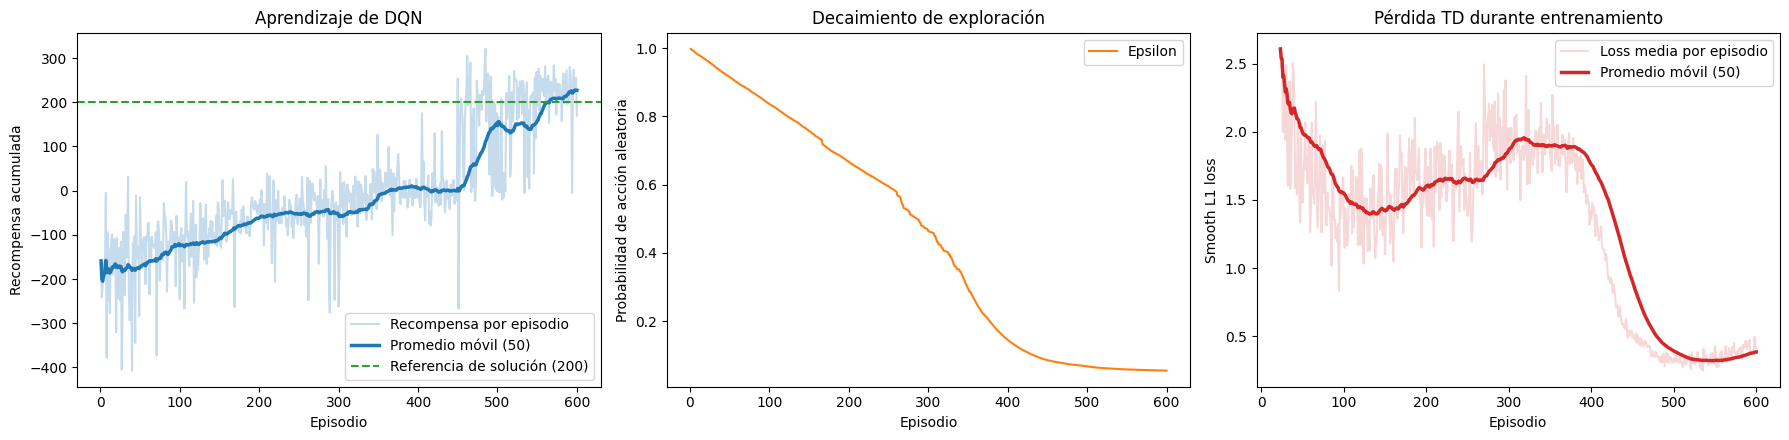

Gráfica guardada en: artifacts/training_curve.png


In [11]:
def rolling_mean(values, window=50):
    values = np.asarray(values, dtype=float)
    return np.array([np.nanmean(values[max(0, i - window + 1): i + 1]) for i in range(len(values))])


episodes = np.arange(1, len(episode_rewards) + 1)
rewards_ma50 = rolling_mean(episode_rewards, window=50)
losses_ma50 = rolling_mean(episode_losses, window=50)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
axes[0].plot(episodes, episode_rewards, color="tab:blue", alpha=0.25, label="Recompensa por episodio")
axes[0].plot(episodes, rewards_ma50, color="tab:blue", linewidth=2.5, label="Promedio móvil (50)")
axes[0].axhline(200, color="tab:green", linestyle="--", label="Referencia de solución (200)")
axes[0].set(title="Aprendizaje de DQN", xlabel="Episodio", ylabel="Recompensa acumulada")
axes[0].legend()

axes[1].plot(episodes, epsilon_history, color="tab:orange", label="Epsilon")
axes[1].set(title="Decaimiento de exploración", xlabel="Episodio", ylabel="Probabilidad de acción aleatoria")
axes[1].legend()

axes[2].plot(episodes, episode_losses, color="tab:red", alpha=0.18, label="Loss media por episodio")
axes[2].plot(episodes, losses_ma50, color="tab:red", linewidth=2.5, label="Promedio móvil (50)")
axes[2].set(title="Pérdida TD durante entrenamiento", xlabel="Episodio", ylabel="Smooth L1 loss")
axes[2].legend()

fig.tight_layout()
plot_path = ARTIFACTS_DIR / "training_curve.png"
fig.savefig(plot_path, dpi=160, bbox_inches="tight")
plt.show()

np.savez(
    ARTIFACTS_DIR / "training_metrics.npz",
    episode_rewards=np.asarray(episode_rewards),
    episode_losses=np.asarray(episode_losses),
    epsilon_history=np.asarray(epsilon_history),
)
print(f"Gráfica guardada en: {plot_path}")

## 7. Evaluación sin exploración

Durante la evaluación usamos `epsilon = 0`: la nave siempre selecciona la acción con mayor Q estimado. Así medimos la política aprendida, no el comportamiento aleatorio usado durante el entrenamiento.

### Cómo interpretar la recompensa y el combustible

No hay una recompensa fija para cada estado aislado: la recompensa pertenece a una **transición** `(estado, acción, siguiente estado)`. El ambiente da retroalimentación densa por acercarse a la plataforma, reducir velocidad y mantener una orientación adecuada; premia el contacto seguro de las patas y penaliza el choque y el uso de propulsores.

Para analizar el combustible no medimos litros físicos. Usamos un **proxy de coste de propulsión**: cada activación del propulsor principal aporta un coste de `0.30` y cada propulsor lateral uno de `0.03`, coherente con los términos de recompensa del ambiente. Es una métrica auxiliar, no una recompensa adicional.

In [12]:
ACTION_LABELS = ["Sin propulsión", "Lateral izquierdo", "Principal", "Lateral derecho"]


def evaluate_policy(policy_net, episodes=20):
    """Evalúa la política greedy y conserva métricas interpretables por episodio."""
    eval_env = gym.make("LunarLander-v3")
    rewards, lengths, action_counts, fuel_costs = [], [], [], []

    policy_net.eval()
    for episode in range(episodes):
        state, _ = eval_env.reset(seed=SEED + 10_000 + episode)
        total_reward = 0.0
        counts = np.zeros(n_actions, dtype=int)

        for step in range(MAX_STEPS_PER_EPISODE):
            action = select_action(state, epsilon=0.0, policy_net=policy_net, n_actions=n_actions)
            state, reward, terminated, truncated, _ = eval_env.step(action)
            counts[action] += 1
            total_reward += reward
            if terminated or truncated:
                break

        rewards.append(total_reward)
        lengths.append(step + 1)
        action_counts.append(counts)
        fuel_costs.append(0.30 * counts[2] + 0.03 * (counts[1] + counts[3]))

    eval_env.close()
    return {
        "rewards": np.asarray(rewards),
        "lengths": np.asarray(lengths),
        "action_counts": np.asarray(action_counts),
        "fuel_costs": np.asarray(fuel_costs),
    }


evaluation = evaluate_policy(policy_net, episodes=20)
evaluation_rewards = evaluation["rewards"]
print(f"Promedio de evaluación (20 episodios): {evaluation_rewards.mean():.2f} ± {evaluation_rewards.std():.2f}")
print(f"Episodios con recompensa ≥ 200: {(evaluation_rewards >= 200).sum()}/20")
print("Recompensas de evaluación:", np.round(evaluation_rewards, 1))
print(f"Coste medio de propulsión (proxy): {evaluation['fuel_costs'].mean():.2f}")

Promedio de evaluación (20 episodios): 241.31 ± 30.05
Episodios con recompensa ≥ 200: 18/20
Recompensas de evaluación: [257.3 274.5 245.  235.6 222.9 189.  247.  279.3 206.3 298.5 223.8 260.1
 245.2 243.4 173.4 257.9 240.8 227.  220.5 278.7]
Coste medio de propulsión (proxy): 63.18


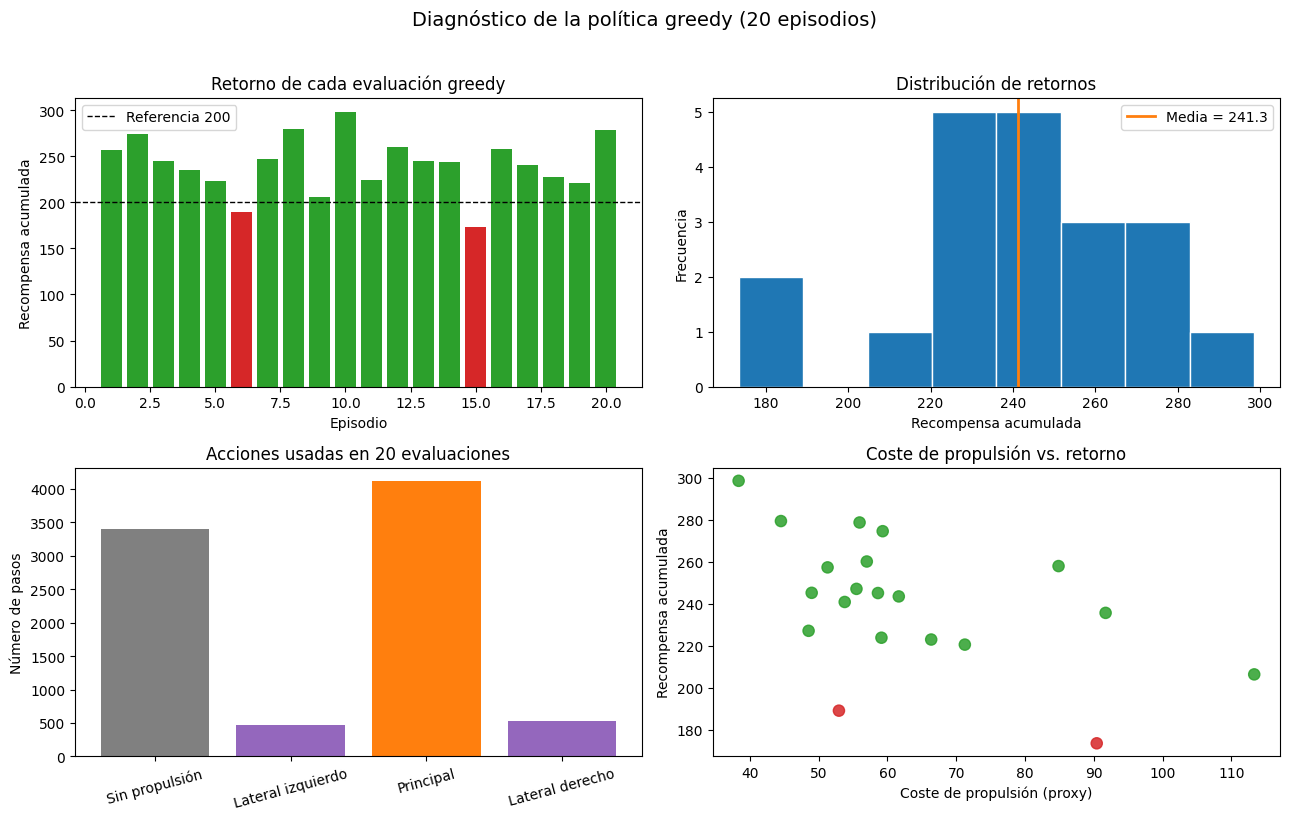

Uso total de acciones:
  Sin propulsión: 3400
  Lateral izquierdo: 475
  Principal: 4111
  Lateral derecho: 533
Duración media: 425.9 pasos
Diagnóstico guardado en: artifacts/evaluation_diagnostics.png


In [13]:
# Diagnósticos de la política evaluada: retorno, duración, acciones y coste de propulsión.
episode_ids = np.arange(1, len(evaluation_rewards) + 1)
success = evaluation_rewards >= 200

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

colors = np.where(success, "tab:green", "tab:red")
axes[0, 0].bar(episode_ids, evaluation_rewards, color=colors)
axes[0, 0].axhline(200, color="black", linestyle="--", linewidth=1, label="Referencia 200")
axes[0, 0].set(title="Retorno de cada evaluación greedy", xlabel="Episodio", ylabel="Recompensa acumulada")
axes[0, 0].legend()

axes[0, 1].hist(evaluation_rewards, bins=8, color="tab:blue", edgecolor="white")
axes[0, 1].axvline(evaluation_rewards.mean(), color="tab:orange", linewidth=2, label=f"Media = {evaluation_rewards.mean():.1f}")
axes[0, 1].set(title="Distribución de retornos", xlabel="Recompensa acumulada", ylabel="Frecuencia")
axes[0, 1].legend()

total_actions = evaluation["action_counts"].sum(axis=0)
axes[1, 0].bar(ACTION_LABELS, total_actions, color=["gray", "tab:purple", "tab:orange", "tab:purple"])
axes[1, 0].tick_params(axis="x", rotation=15)
axes[1, 0].set(title="Acciones usadas en 20 evaluaciones", ylabel="Número de pasos")

axes[1, 1].scatter(evaluation["fuel_costs"], evaluation_rewards, c=colors, s=65, alpha=0.85)
axes[1, 1].set(title="Coste de propulsión vs. retorno", xlabel="Coste de propulsión (proxy)", ylabel="Recompensa acumulada")

fig.suptitle("Diagnóstico de la política greedy (20 episodios)", y=1.02, fontsize=14)
fig.tight_layout()
diagnostics_path = ARTIFACTS_DIR / "evaluation_diagnostics.png"
fig.savefig(diagnostics_path, dpi=160, bbox_inches="tight")
plt.show()

print("Uso total de acciones:")
for label, count in zip(ACTION_LABELS, total_actions):
    print(f"  {label}: {count}")
print(f"Duración media: {evaluation['lengths'].mean():.1f} pasos")
print(f"Diagnóstico guardado en: {diagnostics_path}")

In [14]:
def save_greedy_episode_as_gif(policy_net, seed=SEED + 20_000):
    render_env = gym.make("LunarLander-v3", render_mode="rgb_array")
    state, _ = render_env.reset(seed=seed)
    frames = [render_env.render()]
    total_reward = 0.0

    policy_net.eval()
    for step in range(MAX_STEPS_PER_EPISODE):
        action = select_action(state, epsilon=0.0, policy_net=policy_net, n_actions=n_actions)
        state, reward, terminated, truncated, _ = render_env.step(action)
        total_reward += reward

        # Guardar uno de cada tres cuadros mantiene el GIF ligero.
        if step % 3 == 0:
            frames.append(render_env.render())

        if terminated or truncated:
            break

    render_env.close()
    gif_path = ARTIFACTS_DIR / "lunarlander_greedy_episode.gif"
    imageio.mimsave(gif_path, frames, fps=20, loop=0)
    return gif_path, total_reward, len(frames)


# Reproducimos el mejor episodio de la evaluación para una evidencia visual representativa.
best_eval_index = int(evaluation_rewards.argmax())
best_eval_seed = SEED + 10_000 + best_eval_index
gif_path, gif_reward, frame_count = save_greedy_episode_as_gif(policy_net, seed=best_eval_seed)
print(f"GIF guardado en: {gif_path}")
print(f"Semilla del mejor episodio evaluado: {best_eval_seed}")
print(f"Recompensa del episodio mostrado: {gif_reward:.2f}")
print(f"Cuadros guardados: {frame_count}")

GIF guardado en: artifacts/lunarlander_greedy_episode.gif
Semilla del mejor episodio evaluado: 10051
Recompensa del episodio mostrado: 298.53
Cuadros guardados: 90


### Episodio de evaluación

El siguiente GIF corresponde al mejor de los 20 episodios evaluados sin exploración (`epsilon = 0`).

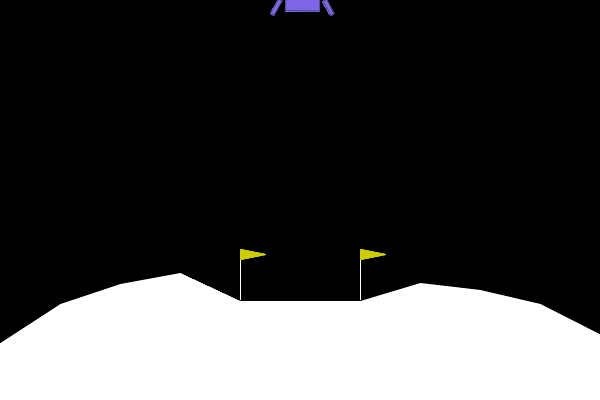

In [15]:
from IPython.display import Image, display

display(Image(filename=str(gif_path)))

## 8. Hiperparámetros y sensibilidad

Los hiperparámetros base se eligieron como un punto de partida razonable, no como una configuración demostrada óptima: `gamma=0.99` valora consecuencias futuras; `learning_rate=5e-4` controla el tamaño de las actualizaciones; lote de 64 y buffer de 100.000 equilibran diversidad y coste; y el decaimiento de epsilon de 50.000 pasos permite explorar antes de explotar. La arquitectura `8 → 128 → 128 → 4` tiene capacidad suficiente para este vector de estado pequeño sin ser excesivamente grande.

Para no afirmar que esos valores son arbitrarios, se ejecutó una **búsqueda acotada**: tres configuraciones (`base`, tasa de aprendizaje a la mitad y exploración más lenta), dos semillas por configuración, 600 episodios por corrida y evaluación greedy de 10 episodios. No es una búsqueda exhaustiva ni suficiente para declarar un ganador estadísticamente robusto; sí sirve para examinar sensibilidad y justificar la elección base.

Resumen de búsqueda acotada (2 semillas por configuración):
  base: retorno = 117.4 ± 128.2; éxito ≥200 = 45%
  learning_rate_baja: retorno = 92.6 ± 81.9; éxito ≥200 = 20%
  exploracion_mas_lenta: retorno = -52.1 ± 51.4; éxito ≥200 = 0%


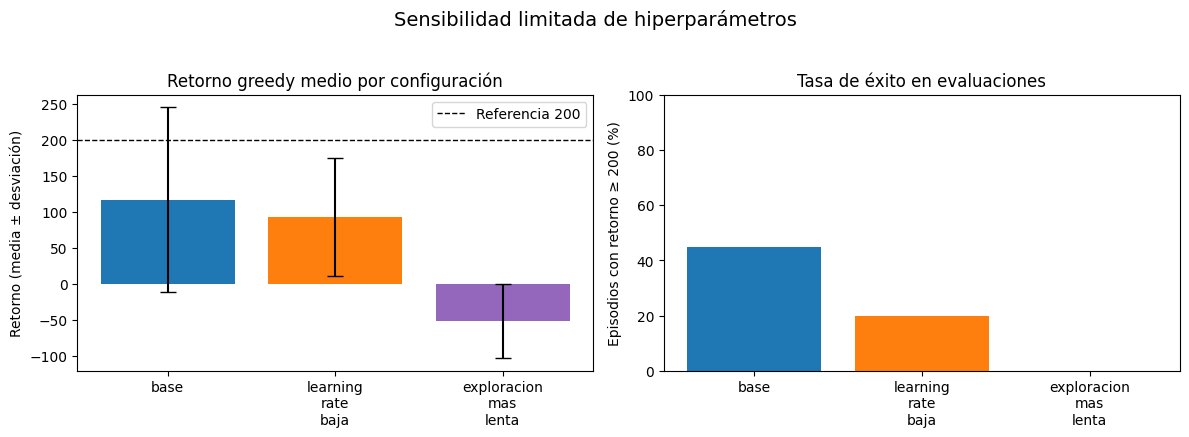

Interpretación: la configuración base fue la mejor de las tres en este barrido,
pero su desviación alta entre dos semillas evidencia que el resultado aún es sensible al azar.
Gráfica guardada en: artifacts/hyperparameter_sweep/sweep_comparison.png


In [16]:
# Esta celda lee resultados reproducibles generados por sweep_hyperparameters.py.
import csv

sweep_dir = ARTIFACTS_DIR / "hyperparameter_sweep"
summary_path = sweep_dir / "sweep_summary.csv"

if not summary_path.exists():
    print("No se encontraron resultados del barrido. Ejecuta: ./.venv/bin/python sweep_hyperparameters.py")
else:
    with summary_path.open(newline="") as file:
        sweep_summary = list(csv.DictReader(file))

    print("Resumen de búsqueda acotada (2 semillas por configuración):")
    for row in sweep_summary:
        print(
            f"  {row['configuracion']}: retorno = {float(row['evaluacion_media']):.1f} ± "
            f"{float(row['evaluacion_desviacion']):.1f}; éxito ≥200 = {100 * float(row['tasa_exito']):.0f}%"
        )

    labels = [row['configuracion'].replace('_', '\n') for row in sweep_summary]
    mean_returns = np.array([float(row['evaluacion_media']) for row in sweep_summary])
    std_returns = np.array([float(row['evaluacion_desviacion']) for row in sweep_summary])
    success_rates = 100 * np.array([float(row['tasa_exito']) for row in sweep_summary])
    x = np.arange(len(labels))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
    axes[0].bar(x, mean_returns, yerr=std_returns, capsize=6, color=["tab:blue", "tab:orange", "tab:purple"])
    axes[0].axhline(200, color="black", linestyle="--", linewidth=1, label="Referencia 200")
    axes[0].set(title="Retorno greedy medio por configuración", ylabel="Retorno (media ± desviación)", xticks=x, xticklabels=labels)
    axes[0].legend()

    axes[1].bar(x, success_rates, color=["tab:blue", "tab:orange", "tab:purple"])
    axes[1].set(title="Tasa de éxito en evaluaciones", ylabel="Episodios con retorno ≥ 200 (%)", ylim=(0, 100), xticks=x, xticklabels=labels)

    fig.suptitle("Sensibilidad limitada de hiperparámetros", y=1.03, fontsize=14)
    fig.tight_layout()
    sweep_plot_path = sweep_dir / "sweep_comparison.png"
    fig.savefig(sweep_plot_path, dpi=160, bbox_inches="tight")
    plt.show()

    print("Interpretación: la configuración base fue la mejor de las tres en este barrido,")
    print("pero su desviación alta entre dos semillas evidencia que el resultado aún es sensible al azar.")
    print(f"Gráfica guardada en: {sweep_plot_path}")

## 9. Discusión, límites, trabajo futuro y fuentes

**Qué funcionó.** DQN puede usar un estado continuo de 8 valores porque la red neuronal aproxima la función Q; las acciones siguen siendo discretas, por lo que el máximo sobre acciones es directo. El replay buffer, la red objetivo y la exploración epsilon-greedy estabilizan y posibilitan el aprendizaje. En la corrida principal, la evaluación greedy obtuvo 241.31 ± 30.05 y 18/20 episodios con retorno mayor o igual a 200.

**Qué no permite concluir.** Un episodio alto, e incluso una sola evaluación favorable, no prueba que la política sea robusta. El barrido muestra alta variabilidad entre semillas: una segunda corrida con la configuración base tuvo un resultado bajo. Por eso el resultado se reporta como evidencia de una política útil, no como garantía de convergencia universal ni como una configuración óptima.

### Qué haríamos con más tiempo o cómputo

1. Repetir cada configuración con 5 a 10 semillas y más episodios, reportando media e intervalo de confianza.
2. Hacer una búsqueda más sistemática de tasa de aprendizaje, decaimiento de epsilon, tamaño de lote, frecuencia de la red objetivo y tamaño de la red.
3. Separar semillas de validación y de prueba para escoger hiperparámetros sin evaluar sobre los mismos episodios.
4. Probar Double DQN para reducir sobreestimación de valores Q y, como extensiones, Dueling DQN o prioridad en replay.
5. Analizar fallos visualmente: trayectorias con aterrizaje brusco, exceso de propulsión o corrección lateral tardía.

**Fuente base.** [PyTorch - Reinforcement Learning (DQN) Tutorial](https://docs.pytorch.org/tutorials/intermediate/reinforcement_q_learning.html).

**Adaptaciones propias.** Se sustituyó `CartPole-v1` por `LunarLander-v3`; la entrada cambió de 4 a 8 variables y la salida de 2 a 4 acciones. Se añadieron semillas, almacenamiento del mejor modelo, curvas de recompensa/epsilon/loss, evaluación de 20 episodios, diagnóstico de acciones y propulsión, búsqueda acotada de hiperparámetros y un GIF de la política greedy.

**Ambiente.** [Gymnasium - LunarLander-v3](https://gymnasium.farama.org/environments/box2d/lunar_lander/).